# RHEED Simulator Configuration Guide
Sumner B. Harris, 3-11-26

This notebook uses a simplified RHEED simulator to visualize diffraction patterns from crystalline surfaces.
The main configuration is controlled by the `RHEEDConfig` object, which defines the crystal structure,
experimental geometry, and rendering options.

This guide explains what each parameter does, the physical assumptions behind the model,
and when the simulator is useful.

---

# Basic Usage

A simulation is configured by creating a `RHEEDConfig` object:

```
cfg = RHEEDConfig(
    lattice=lattice,
    frac=frac,
    weights=weights,
    surface_t1=np.array([1,0,0]),
    surface_t2=np.array([0,1,0]),
    azimuth_deg=0,
    E_keV=20.0,
    theta_deg=3.0,
)
```

Then run

```
I, xd, yd = simulate_rheed(cfg)
```

which returns the simulated detector image.

---

# Crystal Structure Parameters

### Read from a CIF
``` python
lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")
```
or define manually
### Manual lattice

Defines the **unit cell vectors** in Å.

Example:

```
lattice = lattice_from_cell(a, b, c, alpha, beta, gamma)
```

For cubic SrTiO3:

```
lattice = lattice_from_cell(3.905,3.905,3.905,90,90,90)
```

---

### frac

Fractional atomic coordinates inside the unit cell.

Example:

```
frac = np.array([
[0,0,0],
[0.5,0.5,0.5],
[0.5,0.5,0],
[0.5,0,0.5],
[0,0.5,0.5]
])
```

---

### weights

Relative scattering strength of each atom.

These are **approximate electron scattering amplitudes**.
Often atomic number is used as a simple approximation.

Example:

```
weights = np.array([38,22,8,8,8])
```

---

# Surface Orientation

### surface_t1

First **in‑plane lattice direction** of the surface.

Example:

```
surface_t1 = np.array([1,0,0])
```

### surface_t2

Second **in‑plane lattice direction** of the surface.

Example:

```
surface_t2 = np.array([0,1,0])
```

These two vectors define the surface plane.  
The surface normal is:

```
n = surface_t1 × surface_t2
```


---

# Beam Geometry

### E_keV

Electron energy in keV.

Typical RHEED values:

```
10 – 30 keV
```

Higher energy shortens the electron wavelength.

---

### theta_deg

Incident angle relative to the surface plane.

Typical values:

```
1° – 5°
```

Small angles increase surface sensitivity.

---

### azimuth_deg

Rotation of the crystal around the surface normal.

```
azimuth = 0° → beam aligned with surface_t1
azimuth = 90° → beam aligned with surface_t2
```

Example:

```
0°  = [100] azimuth
45° = [110] azimuth
```

---

# Detector Geometry

### d_mm

Distance from sample to phosphor screen.

Typical RHEED distances:

```
100 – 500 mm
```

This controls the scale of the diffraction pattern.

---

### xlim_mm

Horizontal screen limits.

Example:

```
xlim_mm = (-30,30)
```

### ylim_mm

Vertical screen limits.

Example:

```
ylim_mm = (-60,10)
```

Often the **shadow edge** occurs near `y=0`.

---

### N

Detector grid resolution.

Example:

```
N = 400
```

Higher values give smoother images but increase computation time.

---

# Broadening Parameters

### Broadening2D

Controls the width of diffraction rods and nodes.

| parameter | meaning |
|---|---|
| sigma_qpar | in‑plane broadening |
| sigma_qz_backbone | rod length |
| node_scale | intensity of node features |

These parameters represent:

• finite coherence length  
• surface roughness  
• instrumental broadening  

---

# Specular and Direct Beam

### BroadeningSpecular

Controls the appearance of the **00/specular beam** and optional **direct beam**.

Example:

```
broad00 = BroadeningSpecular(
    add=True,
    scale=0.7,
    sigma_x_mm=0.45,
    sigma_y_mm=0.65,
    add_direct=True
)
```

If `add_direct=True`, the simulator also draws the **direct beam** (beam that misses the sample).

A halo can also be simulated to represent:

• gas scattering  
• phosphor blooming  

---

# Shadow Edge

Optional shadow mask:

```
shadow = ShadowMask(
    enabled=True,
    y_edge_mm=0
)
```

This blocks scattered signal above the horizon, while leaving the direct beam visible.

---

# Kikuchi Bands

Optional Kikuchi pattern rendering.

These arise from **inelastic scattering followed by diffraction**.

Controls include:

| parameter | meaning |
|---|---|
| enabled | toggle Kikuchi rendering |
| width_deg | band width |
| scale | intensity |

Kikuchi bands provide crystallographic orientation information.

---

# Model Assumptions

The simulator uses a **kinematic diffraction model** with several simplifications:

1. Single‑scattering approximation  
2. Surface truncation rods  
3. Finite coherence broadening  
4. Gaussian detector response  
5. Approximate atomic scattering factors  

---

# 3D Diffraction Component

The simulator optionally includes a **3D bulk diffraction component**
in addition to the surface truncation rods. This is controlled by
the `Broadening3D` parameters.

Physically this represents scattering from a crystal with **finite
coherence depth** along the surface normal.

In an ideal infinite crystal diffraction occurs only at discrete
reciprocal lattice points.

In real RHEED experiments limited penetration depth broadens these
points along reciprocal‑space rods.

---

# Broadening3D Parameters

Example:

```
broad3d = Broadening3D(
    enabled=True,
    sigma_qpar=0.03,
    sigma_qz=0.20,
    scale=0.6
)
```

### enabled

Turns the 3D diffraction component on or off.

### sigma_qpar

In‑plane broadening of the reciprocal lattice peaks.

Physical meaning:

• finite lateral coherence length  
• surface disorder  
• instrumental angular spread  

Larger values broaden spots horizontally.

### sigma_qz

Broadening along the surface‑normal direction in reciprocal space.

Represents:

• finite crystal thickness  
• electron penetration depth  
• imperfect lattice periodicity

### scale

Relative intensity of the bulk Bragg reflections.

---

# Relationship Between 2D and 3D Diffraction

Two limiting regimes exist:

### Surface truncation (2D)

Crystal truncation produces **reciprocal rods**.
Intersections with the Ewald sphere create streaks.

### Bulk periodicity (3D)

Periodic lattice produces **discrete Bragg spots**.

Real RHEED patterns often contain a mixture of both.

---

# How Intensities Are Combined

The final simulated intensity is the sum of several components:

```
I_total =
    I_2D_rods
  + I_3D_bragg
  + I_specular
  + I_kikuchi
```

Where:

| component | origin |
|---|---|
| I_2D_rods | surface truncation rods |
| I_3D_bragg | broadened bulk reflections |
| I_specular | specular reflection |
| I_kikuchi | Kikuchi bands |

---

# Detector Response

After summing contributions the detector response is approximated
with a Gaussian blur:

```
I_final = blur(I_total)
```

This represents:

• phosphor spread  
• camera optics  
• instrument resolution  

---

# Limitations

This simulator **does not include dynamical electron diffraction**.

Therefore:

• spot positions are reliable  
• intensities are qualitative  

It is best used for:

• exploring surface symmetry  
• identifying reconstructions  
• understanding RHEED geometry  

rather than quantitative intensity modeling.

---

# Summary

This simulator provides a **fast geometric visualization of RHEED patterns**
based on crystal structure and diffraction geometry.

It is a useful **interpretation tool**, but not a replacement
for full dynamical RHEED calculations.

Also, probably able to use this to generate training data for ML models.

In [9]:
from rheed_qspace_phenom_model import *
import pymatgen
import matplotlib.pyplot as plt

# Various Demo Simulations

# SrTiO3 - Substrate-like with Direct beam and Shadow Edge

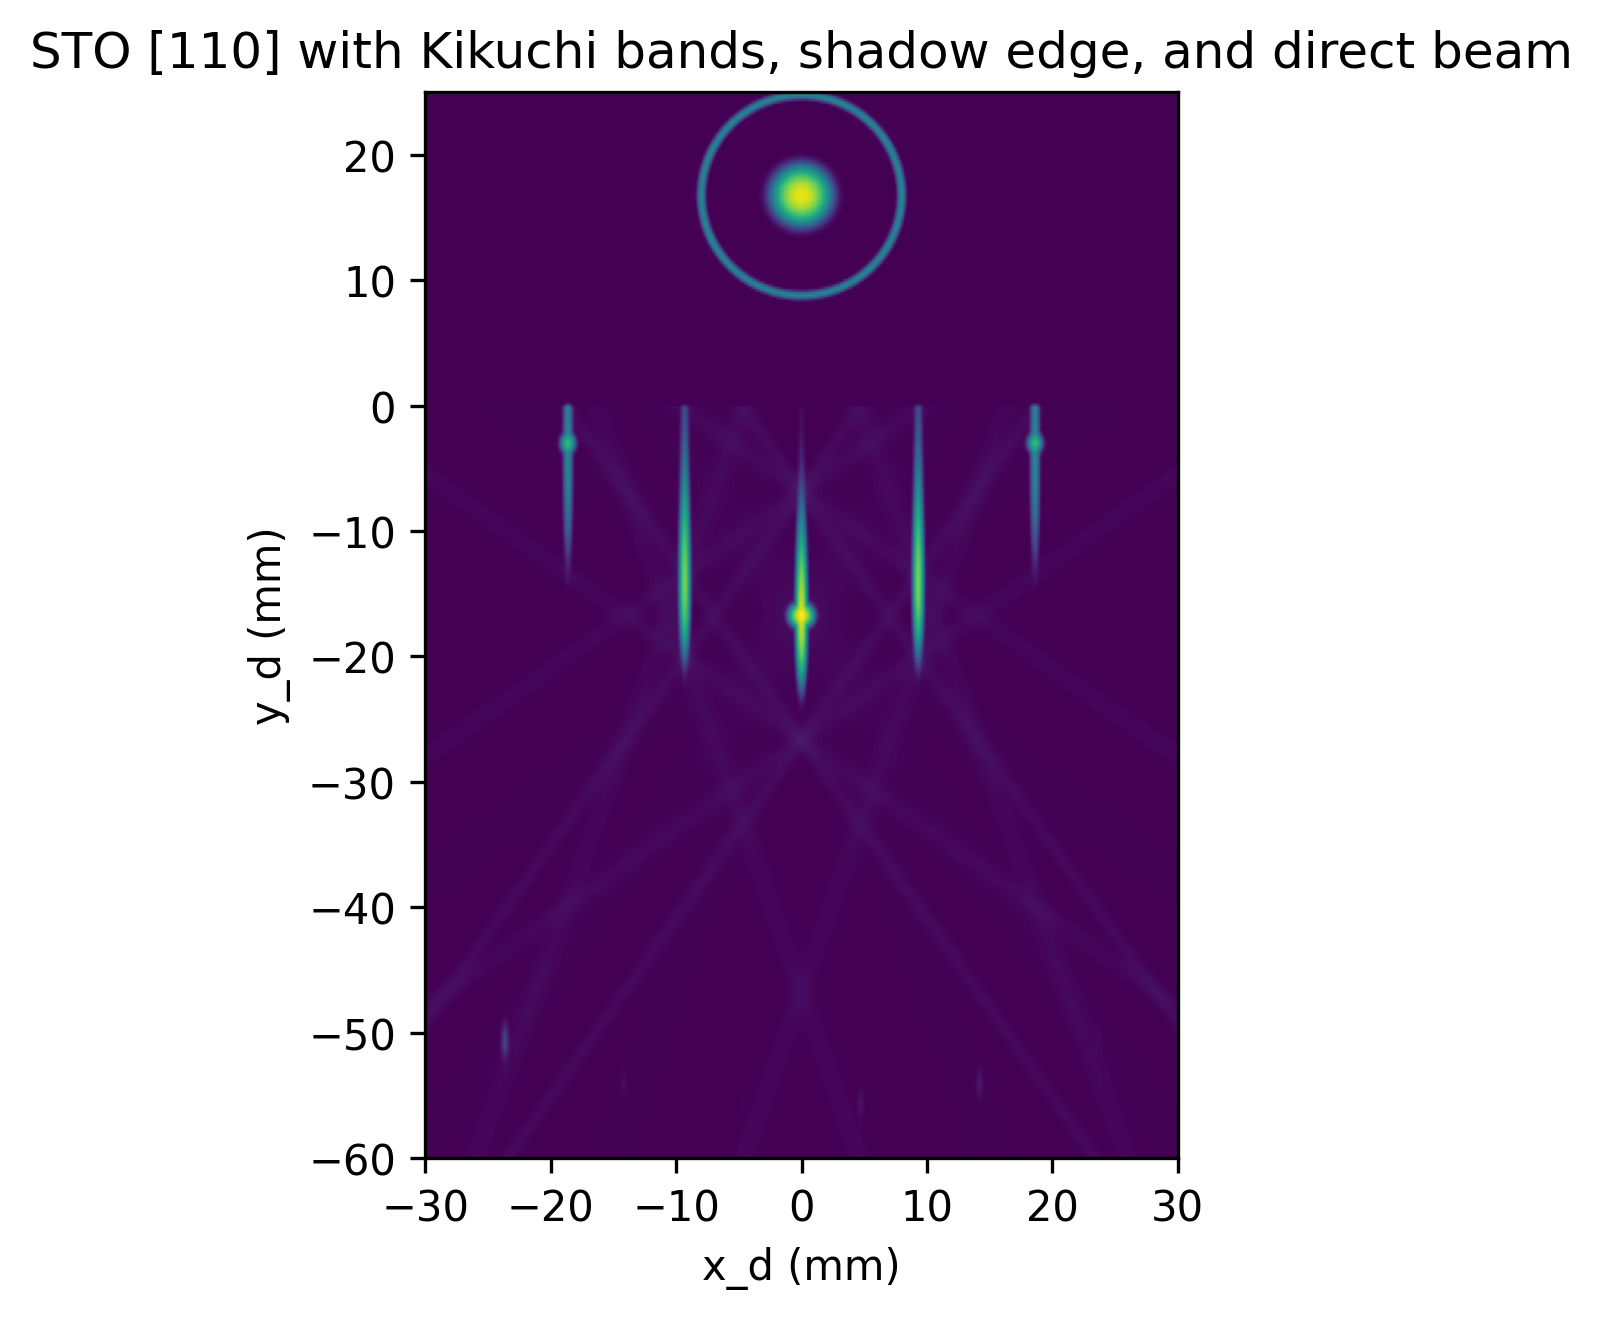

In [21]:
lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")

cfg = RHEEDConfig(
    title="STO [110] with Kikuchi bands, shadow edge, and direct beam",
    lattice=lattice,
    frac=frac,
    weights=weights,
    surface_t1 = (1, 0, 0),
    surface_t2 = (0, 1, 0),
    azimuth_deg=45.0,  # [110] in this convention
    E_keV=20.0,
    theta_deg=3.2,
    d_mm = 300.0,
    xlim_mm=(-30, 30.0),
    ylim_mm=(-60.0, 25),
    N=420,
    hmax2d=6,
    kmax2d=6,
    hmax3d=3,
    kmax3d=3,
    lmax3d=3,
    broad2d=Broadening2D(
        sigma_qpar=0.028,
        sigma_qz_backbone=2.3,
        sigma_node_x_mm=0.20,
        sigma_node_y_mm=0.28,
        node_scale=20,
    ),
    broad3d=Broadening3D(
        sigma_qpar=0.050,
        sigma_qz=0.045,
        sigma_family=1.0,
        weight_scale=0.0,
        top_fraction=0.999,
    ),
    broad00=BroadeningSpecular(
        add=True,
        scale=1e4,
        sigma_x_mm=0.3,
        sigma_y_mm=0.3,
    
        add_direct=True,
        direct_scale=1e4,
        direct_sigma_x_mm=0.7,
        direct_sigma_y_mm=0.7,
        direct_halo_scale=1e2,
        direct_halo_radius_mm=8.0,
        direct_halo_sigma_mm=0.1,
    ),
    screen=ScreenBlur(
        sigma_x_mm=0.10,
        sigma_y_mm=0.10,
    ),
    shadow=ShadowMask(
        enabled=True,   # OFF by default for backward compatibility
        y_edge_mm=0.0,
    ),
    kikuchi=KikuchiParams(
        enabled=True,          # ON / OFF option
        hmax=3,
        kmax=3,
        l_values=(1,2),
        max_order_sum=5,
        sigma_edge_base=0.00035,   # width tuning
        sigma_edge_scale=0.05,     # width tuning
        sigma_fill_base=0.00070,   # width tuning
        sigma_fill_scale=0.18,     # width tuning
        edge_scale=2.0,            # band-edge intensity tuning
        fill_scale=0.5,            # band interior intensity tuning
        blend_scale=1,          # overall Kikuchi intensity tuning
        include_signed_families=True,
    ),
    ewald_tol=0.06,
    ewald_sigma=0.025,
)

res = simulate_rheed(cfg)

plt.figure(figsize=(6, 4.5),dpi=300)
plt.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower",
    aspect="equal",
)
plt.xlabel("x_d (mm)")
plt.ylabel("y_d (mm)")
plt.title(cfg.title)
plt.tight_layout()
plt.show()

# SrTiO3 - Substrate-Like

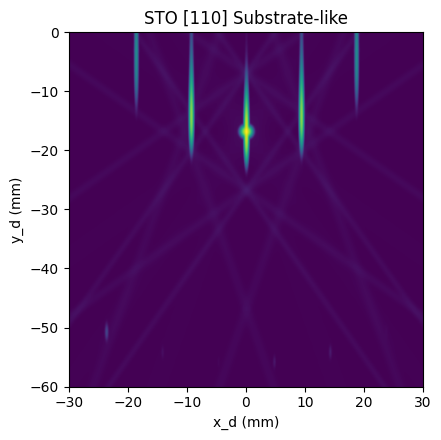

In [6]:
lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")

cfg = RHEEDConfig(
    title="STO [110] Substrate-like",
    lattice=lattice,
    frac=frac,
    weights=weights,
    azimuth_deg=45.0,  # [110] in this convention
    E_keV=20.0,
    theta_deg=3.2,
    xlim_mm=(-30, 30.0),
    ylim_mm=(-60.0, 0.0),
    N=420,
    hmax2d=6,
    kmax2d=6,
    hmax3d=3,
    kmax3d=3,
    lmax3d=3,
    broad2d=Broadening2D(
        sigma_qpar=0.028,
        sigma_qz_backbone=2.3,
        sigma_node_x_mm=0.20,
        sigma_node_y_mm=0.28,
        node_scale=0.08,
    ),
    broad3d=Broadening3D(
        sigma_qpar=0.050,
        sigma_qz=0.045,
        sigma_family=1.0,
        weight_scale=0.0,
        top_fraction=0.999,
    ),
    broad00=BroadeningSpecular(
        add=True,
        scale=5e3,
        sigma_x_mm=0.35,
        sigma_y_mm=0.35,
    ),
    screen=ScreenBlur(
        sigma_x_mm=0.10,
        sigma_y_mm=0.10,
    ),
    kikuchi=KikuchiParams(
        enabled=True,          # ON / OFF option
        hmax=3,
        kmax=3,
        l_values=(1,2),
        max_order_sum=5,
        sigma_edge_base=0.00035,   # width tuning
        sigma_edge_scale=0.05,     # width tuning
        sigma_fill_base=0.00070,   # width tuning
        sigma_fill_scale=0.18,     # width tuning
        edge_scale=2.0,            # band-edge intensity tuning
        fill_scale=0.5,            # band interior intensity tuning
        blend_scale=1,          # overall Kikuchi intensity tuning
        include_signed_families=True,
    ),
    ewald_tol=0.06,
    ewald_sigma=0.025,
)

res = simulate_rheed(cfg)

plt.figure(figsize=(6, 4.5))
plt.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower",
    aspect="equal",
)
plt.xlabel("x_d (mm)")
plt.ylabel("y_d (mm)")
plt.title(cfg.title)
plt.tight_layout()
plt.show()

# SrTiO3 Film-like

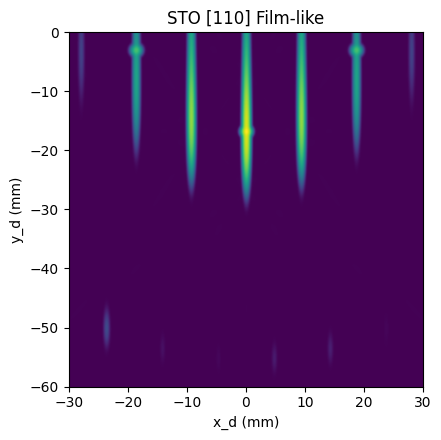

In [7]:
lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")

cfg = RHEEDConfig(
    title="STO [110] Film-like",
    lattice=lattice,
    frac=frac,
    weights=weights,
    azimuth_deg=45.0,  # [110] in this convention
    E_keV=20.0,
    theta_deg=3.2,
    xlim_mm=(-30, 30.0),
    ylim_mm=(-60.0, 0.0),
    N=420,
    hmax2d=6,
    kmax2d=6,
    hmax3d=3,
    kmax3d=3,
    lmax3d=3,
    broad2d=Broadening2D(
        sigma_qpar=0.06,
        sigma_qz_backbone=2.3,
        sigma_node_x_mm=0.4,
        sigma_node_y_mm=0.4,
        node_scale=20.0,
    ),
    broad3d=Broadening3D(
        sigma_qpar=0.050,
        sigma_qz=0.045,
        sigma_family=1.0,
        weight_scale=0.0,
        top_fraction=0.999,
    ),
    broad00=BroadeningSpecular(
        add=True,
        scale=5e3,
        sigma_x_mm=0.35,
        sigma_y_mm=0.35,
    ),
    screen=ScreenBlur(
        sigma_x_mm=0.10,
        sigma_y_mm=0.10,
    ),
    kikuchi=KikuchiParams(
        enabled=True,          # ON / OFF option
        hmax=3,
        kmax=3,
        l_values=(1,2),
        max_order_sum=5,
        sigma_edge_base=0.00035,   # width tuning
        sigma_edge_scale=0.05,     # width tuning
        sigma_fill_base=0.00070,   # width tuning
        sigma_fill_scale=0.18,     # width tuning
        edge_scale=2.0,            # band-edge intensity tuning
        fill_scale=0.5,            # band interior intensity tuning
        blend_scale=0.1,          # overall Kikuchi intensity tuning
        include_signed_families=True,
    ),
    ewald_tol=0.06,
    ewald_sigma=0.025,
)

res = simulate_rheed(cfg)

plt.figure(figsize=(6, 4.5))
plt.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower",
    aspect="equal",
)
plt.xlabel("x_d (mm)")
plt.ylabel("y_d (mm)")
plt.title(cfg.title)
plt.tight_layout()
plt.show()

# SrTiO3 3D-like

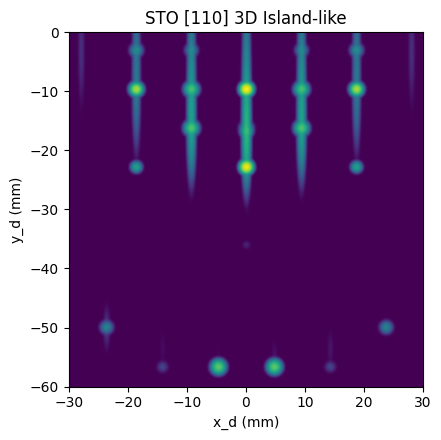

In [8]:
lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")

cfg = RHEEDConfig(
    title="STO [110] 3D Island-like",
    lattice=lattice,
    frac=frac,
    weights=weights,
    azimuth_deg=45.0,  # [110] in this convention
    E_keV=20.0,
    theta_deg=3.2,
    xlim_mm=(-30, 30.0),
    ylim_mm=(-60.0, 0.0),
    N=420,
    hmax2d=6,
    kmax2d=6,
    hmax3d=8,
    kmax3d=8,
    lmax3d=20,
    broad2d=Broadening2D(
        sigma_qpar=0.06,
        sigma_qz_backbone=2.3,
        sigma_node_x_mm=0.4,
        sigma_node_y_mm=0.4,
        node_scale=20.0,
    ),
    broad3d=Broadening3D(
        sigma_qpar=0.080,
        sigma_qz=0.08,
        sigma_family=2.0,
        weight_scale=200,
        top_fraction=0.999,
    ),
    broad00=BroadeningSpecular(
        add=True,
        scale=5e3,
        sigma_x_mm=0.35,
        sigma_y_mm=0.35,
    ),
    screen=ScreenBlur(
        sigma_x_mm=0.10,
        sigma_y_mm=0.10,
    ),
    kikuchi=KikuchiParams(
        enabled=True,          # ON / OFF option
        hmax=3,
        kmax=3,
        l_values=(1,2),
        max_order_sum=5,
        sigma_edge_base=0.00035,   # width tuning
        sigma_edge_scale=0.05,     # width tuning
        sigma_fill_base=0.00070,   # width tuning
        sigma_fill_scale=0.18,     # width tuning
        edge_scale=2.0,            # band-edge intensity tuning
        fill_scale=0.5,            # band interior intensity tuning
        blend_scale=0.1,          # overall Kikuchi intensity tuning
        include_signed_families=True,
    ),
    ewald_tol=0.5,
    ewald_sigma=0.025,
)

res = simulate_rheed(cfg)

plt.figure(figsize=(6, 4.5))

plt.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower",
    aspect="equal",
)
plt.xlabel("x_d (mm)")
plt.ylabel("y_d (mm)")
plt.title(cfg.title)
plt.tight_layout()
plt.show()

# 2x1 Surface Reconstruction of SrTiO3

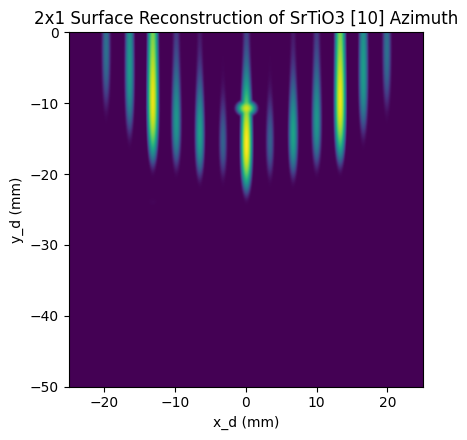

In [11]:
# ------------------------------------------------------------------
# 2x1 STO model:
# doubled along x, with a simple reconstructed second TiO2 half-cell.
# This is illustrative rather than a literature-refined atomic model.
# ------------------------------------------------------------------
lat = lattice_from_cell(7.810, 3.905, 3.905, 90, 90, 90)
weights = np.array([38.0, 22.0, 8.0, 8.0, 8.0, 38.0, 22.0, 8.0, 8.0, 8.0], dtype=float)

frac_bulk = np.array([
    [0.000, 0.000, 0.000],   # Sr
    [0.250, 0.500, 0.500],   # Ti
    [0.250, 0.500, 0.000],   # O
    [0.250, 0.000, 0.500],   # O
    [0.000, 0.500, 0.500],   # O
    [0.500, 0.000, 0.000],   # Sr
    [0.750, 0.500, 0.500],   # Ti
    [0.750, 0.500, 0.000],   # O
    [0.750, 0.000, 0.500],   # O
    [0.500, 0.500, 0.500],   # O
], dtype=float)

# Simple illustrative 2x1 reconstruction:
# one half remains bulk-like, the second half has a shifted/rumpled TiO2 motif
frac_rec = frac_bulk.copy()
frac_rec[6] = [0.780, 0.500, 0.480]   # Ti shift
frac_rec[7] = [0.765, 0.500, 0.000]   # O shift
frac_rec[8] = [0.775, 0.000, 0.510]   # O shift

cfg = RHEEDConfig(
        title="2x1 Surface Reconstruction of SrTiO3 [10] Azimuth",
        lattice=lat,
        frac=frac_rec,
        weights=weights,
        azimuth_deg=0,
        E_keV=20.0,
        theta_deg=3.0,
        xlim_mm=(-25.0, 25.0),
        ylim_mm=(-50.0, 0.0),
        N=350,
        broad2d=Broadening2D(
            sigma_qpar=0.028,
            sigma_qz_backbone=2.3,
            sigma_node_x_mm=0.20,
            sigma_node_y_mm=0.28,
            node_scale=0.0,
        ),
        broad00=BroadeningSpecular(add=False),
        screen=ScreenBlur(sigma_x_mm=0.2, sigma_y_mm=0.2),
    )

res = simulate_rheed(cfg)

plt.figure(figsize=(6, 4.5))
plt.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower",
    aspect="equal",
)
plt.xlabel("x_d (mm)")
plt.ylabel("y_d (mm)")
plt.title(cfg.title)
plt.tight_layout()
plt.show()

# Experimental Parameter Sweeps


Simulating Theta Sweep:  68%|███████████████████████████████████████▍                  | 53/78 [14:16<06:44, 16.16s/it]

Simulating Theta Sweep: 100%|██████████████████████████████████████████████████████████| 78/78 [02:30<00:00,  1.82s/it]
Simulating Theta Sweep: 79it [02:31,  1.77s/it]                                                                        
Simulating Theta Sweep: 80it [02:33,  1.71s/it]
Simulating Theta Sweep: 81it [02:36,  1.93s/it]


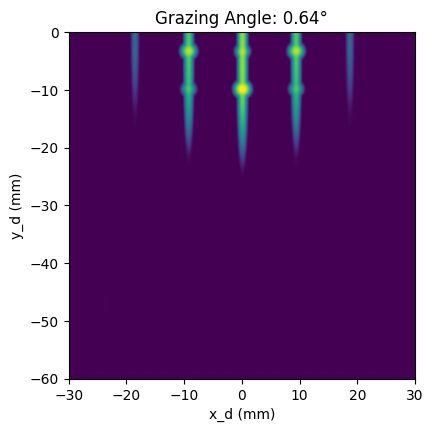

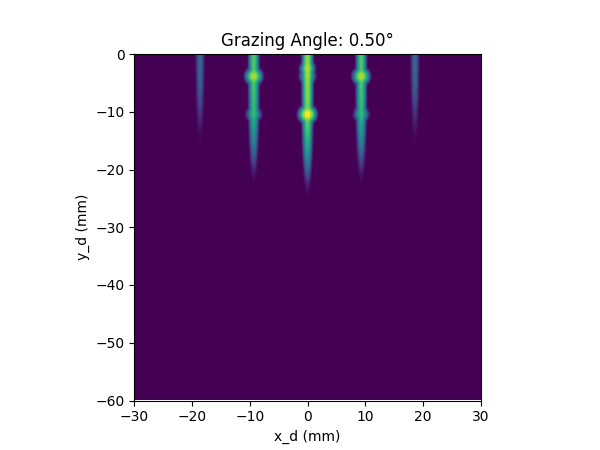

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm import tqdm
from IPython.display import Image

# 1. Define the Grazing Angle Sweep (0.5° to 6.0°)
theta_range = np.linspace(0.5, 6.0, 40) 
yoyo_range = list(theta_range) + list(reversed(theta_range[1:-1]))

lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")

# 2. Setup the Base Configuration
shared_params = {
    "lattice": lattice, 
    "frac": frac,
    "weights": weights,
    "azimuth_deg": 45.0,
    "E_keV": 20.0,        # Fixed Energy
    "xlim_mm": (-30, 30.0),
    "ylim_mm": (-60.0, 0.0),
    "N": 420,
    "hmax2d": 6, "kmax2d": 6,
    "hmax3d": 2, "kmax3d": 2, "lmax3d": 2,
    "broad2d": Broadening2D(sigma_qpar=0.06, sigma_qz_backbone=2.3, sigma_node_x_mm=0.4, sigma_node_y_mm=0.4, node_scale=20),
    "broad3d": Broadening3D(sigma_qpar=0.080, sigma_qz=0.08, sigma_family=2.0, weight_scale=0.0, top_fraction=0.999),
    "broad00": BroadeningSpecular(add=True, scale=5e3, sigma_x_mm=0.35, sigma_y_mm=0.35),
    "screen": ScreenBlur(sigma_x_mm=0.10, sigma_y_mm=0.10),
    "kikuchi": KikuchiParams(enabled=False, hmax=3, kmax=3, l_values=(1,2), max_order_sum=5, 
                             sigma_edge_base=0.00035, sigma_edge_scale=0.05, sigma_fill_base=0.00070, 
                             sigma_fill_scale=0.18, edge_scale=2.0, fill_scale=0.5, blend_scale=1, 
                             include_signed_families=True),
    "ewald_tol": 0.5,
    "ewald_sigma": 0.025,
}

# Setup Initial Plot
fig, ax = plt.subplots(figsize=(6, 4.5))
initial_cfg = RHEEDConfig(title="SrTiO3 Theta Sweep", theta_deg=theta_range[0], **shared_params)
res = simulate_rheed(initial_cfg)

im = ax.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower", aspect="equal", cmap='viridis' # 'magma' or 'viridis' work well here
)
ax.set_xlabel("x_d (mm)")
ax.set_ylabel("y_d (mm)")
title_text = ax.set_title(f"Grazing Angle: {theta_range[0]:.2f}°")

# 3. Progress Bar & Update Function
pbar = tqdm(total=len(yoyo_range), desc="Simulating Theta Sweep")

def update(frame_val):
    # Update theta_deg while keeping everything else fixed
    current_cfg = RHEEDConfig(title="SrTiO3 Theta Sweep", theta_deg=frame_val, **shared_params)
    
    new_res = simulate_rheed(current_cfg)
    
    im.set_data(np.log1p(new_res["I_total"]))
    title_text.set_text(f"Grazing Angle: {frame_val:.2f}°")
    
    pbar.update(1)
    return [im, title_text]

# 4. Create and Save
ani = FuncAnimation(fig, update, frames=yoyo_range, blit=True)

# Save as GIF
writer = PillowWriter(fps=12)
ani.save("theta_sweep.gif", writer=writer)

pbar.close()
plt.show()

Image(filename="theta_sweep.gif")


Simulating Theta Sweep: 81it [10:22,  7.68s/it]                                                                        


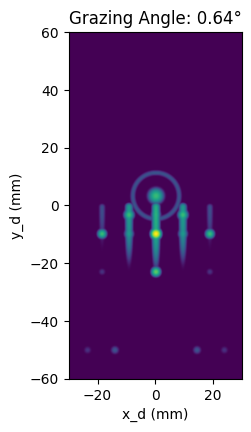

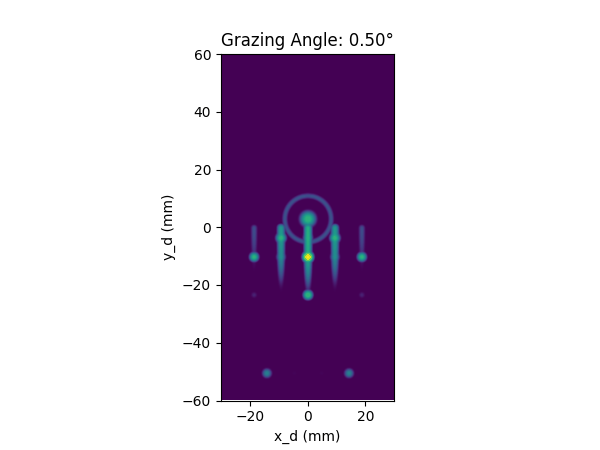

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm import tqdm
from IPython.display import Image

# 1. Define the Grazing Angle Sweep (0.5° to 6.0°)
theta_range = np.linspace(0.5, 6.0, 40) 
yoyo_range = list(theta_range) + list(reversed(theta_range[1:-1]))

lattice, frac, weights = load_structure_from_cif("SrTiO3.cif")

# 2. Setup the Base Configuration
shared_params = {
    "lattice": lattice, 
    "frac": frac,
    "weights": weights,
    "azimuth_deg": 45.0,
    "E_keV": 20.0,        # Fixed Energy
    "xlim_mm": (-30, 30.0),
    "ylim_mm": (-60.0, 60.0),
    "N": 420,
    "hmax2d": 6, "kmax2d": 6,
    "hmax3d": 8, "kmax3d": 8, "lmax3d": 8,
    "broad2d": Broadening2D(sigma_qpar=0.06, sigma_qz_backbone=2.3, sigma_node_x_mm=0.4, sigma_node_y_mm=0.4, node_scale=20),
    "broad3d": Broadening3D(sigma_qpar=0.080, sigma_qz=0.08, sigma_family=2.0, weight_scale=200.0, top_fraction=0.999),
    "broad00": BroadeningSpecular(add=True,scale=0.70, sigma_x_mm=0.45, sigma_y_mm=0.65, add_direct=True,
        direct_scale=1e4, direct_sigma_x_mm=0.7, direct_sigma_y_mm=0.7, direct_halo_scale=1e2,
        direct_halo_radius_mm=8.0, direct_halo_sigma_mm=0.1,),
    "shadow": ShadowMask(enabled=True, y_edge_mm=0.0),
    "kikuchi": KikuchiParams(enabled=False, hmax=3, kmax=3, l_values=(1,2), max_order_sum=5, 
                             sigma_edge_base=0.00035, sigma_edge_scale=0.05, sigma_fill_base=0.00070, 
                             sigma_fill_scale=0.18, edge_scale=2.0, fill_scale=0.5, blend_scale=1, 
                             include_signed_families=True),
    "ewald_tol": 0.5,
    "ewald_sigma": 0.025,
}

# Setup Initial Plot
fig, ax = plt.subplots(figsize=(6, 4.5))
initial_cfg = RHEEDConfig(title="SrTiO3 Theta Sweep", theta_deg=theta_range[0], **shared_params)
res = simulate_rheed(initial_cfg)

im = ax.imshow(
    np.log1p(res["I_total"]),
    extent=[res["xd"][0], res["xd"][-1], res["yd"][0], res["yd"][-1]],
    origin="lower", aspect="equal", cmap='viridis' # 'magma' or 'viridis' work well here
)
ax.set_xlabel("x_d (mm)")
ax.set_ylabel("y_d (mm)")
title_text = ax.set_title(f"Grazing Angle: {theta_range[0]:.2f}°")

# 3. Progress Bar & Update Function
pbar = tqdm(total=len(yoyo_range), desc="Simulating Theta Sweep")

def update(frame_val):
    # Update theta_deg while keeping everything else fixed
    current_cfg = RHEEDConfig(title="SrTiO3 Theta Sweep", theta_deg=frame_val, **shared_params)
    
    new_res = simulate_rheed(current_cfg)
    
    im.set_data(np.log1p(new_res["I_total"]))
    title_text.set_text(f"Grazing Angle: {frame_val:.2f}°")
    
    pbar.update(1)
    return [im, title_text]

# 4. Create and Save
ani = FuncAnimation(fig, update, frames=yoyo_range, blit=True)

# Save as GIF
writer = PillowWriter(fps=12)
ani.save("theta_sweep_direct_beam.gif", writer=writer)

pbar.close()
plt.show()

Image(filename="theta_sweep_direct_beam.gif")